### Grover´s algorithm
### Author: Ismael Ahrazem Dfuf

## Required packages

In [1]:
import pkg_resources

# Get a list of all installed packages and their versions
installed_packages = pkg_resources.working_set

# Print the package name and version
for package in installed_packages:
    print(f"{package.key} == {package.version}")

babel == 2.11.0
brotli == 1.0.9
markupsafe == 2.1.3
pyjwt == 2.10.1
pyqt5 == 5.15.10
pyqt5-sip == 12.13.0
pysocks == 1.7.1
pyyaml == 6.0.2
pygments == 2.15.1
qtpy == 2.4.1
send2trash == 1.8.2
annotated-types == 0.7.0
anyio == 4.6.2
argon2-cffi == 21.3.0
argon2-cffi-bindings == 21.2.0
asttokens == 2.0.5
async-lru == 2.0.4
attrs == 24.2.0
beautifulsoup4 == 4.12.3
bleach == 4.1.0
certifi == 2024.8.30
cffi == 1.17.1
charset-normalizer == 3.3.2
colorama == 0.4.6
comm == 0.2.1
contourpy == 1.3.0
cryptography == 44.0.0
cycler == 0.12.1
debugpy == 1.6.7
decorator == 5.1.1
defusedxml == 0.7.1
dill == 0.3.9
docplex == 2.29.241
executing == 0.8.3
fastjsonschema == 2.16.2
fonttools == 4.54.1
h11 == 0.14.0
httpcore == 1.0.2
httpx == 0.27.0
ibm-cloud-sdk-core == 3.22.1
ibm-platform-services == 0.59.1
idna == 3.7
ipykernel == 6.29.5
ipython == 8.27.0
ipywidgets == 8.1.2
jedi == 0.19.1
jinja2 == 3.1.4
json5 == 0.9.25
jsonschema == 4.23.0
jsonschema-specifications == 2023.7.1
jupyter == 1.0.0
jupyter-c

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from qiskit import *
from qiskit.quantum_info import Statevector, Operator
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import QFT
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import CUGate, CPhaseGate, MCXGate
from qiskit.visualization import plot_histogram, plot_state_qsphere, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [4]:
from qiskit import transpile
from qiskit.circuit.random import random_circuit
from qiskit_ibm_runtime import QiskitRuntimeService

## Deliverable 1

1. How did you construct the Oracle?
2. Are you obtaining the expected results? 
3. How many iterations you required? 

####  Build and execute the Grover circuit

In [5]:
n = 3 ##### Number of qubits

Oracle:

How did you construct the Oracle?

The Multicontrolled ZGate has been implemented using the Multicontrolled XGate with hadamard gates in the Target qubit

w = |q2q1q0> = |000>

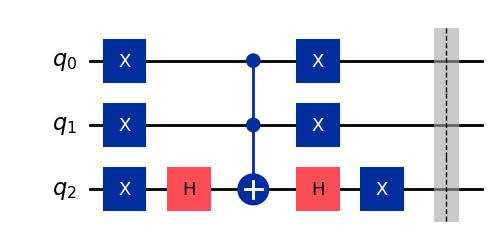

In [6]:
### Oracle

def Uf_oracle(n):
    
    U_f = QuantumCircuit(n)
    for i in range(n):
        U_f.x(i)
        
    U_f.h(n-1)
    U_f.mcx(control_qubits = [0,1], target_qubit = n-1)
    U_f.h(n-1)
    
    for i in range(n):
        U_f.x(i)
    U_f.barrier()
    return U_f

U_f = Uf_oracle(n)
    
U_f.draw('mpl')

Diffuser:

How did you construct the Diffuser?

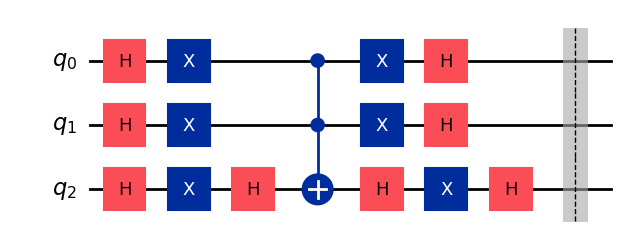

In [7]:
def Diffuser_f(n):
    
    Diffuser = QuantumCircuit(n)
    
    for i in range(n):
        Diffuser.h(i)
    
    for i in range(n):
        Diffuser.x(i)
    
    Diffuser.h(n-1)
    Diffuser.mcx(control_qubits = list(range(n-1)), target_qubit = n-1)
    Diffuser.h(n-1)
    
    for i in range(n):
        Diffuser.x(i)
    
    for i in range(n):
        Diffuser.h(i)

    Diffuser.barrier()
    return Diffuser

Diffuser = Diffuser_f(n)

Diffuser.draw('mpl')

Combine Oracle and Diffuser (Amplitud amplifier)

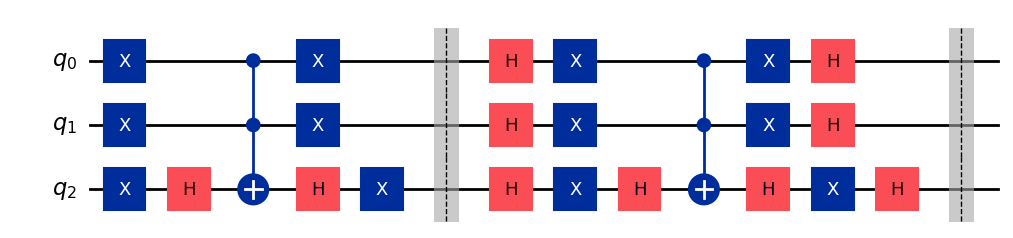

In [8]:
Uf_diffuser_combined = U_f.compose(Diffuser)

Uf_diffuser_combined.draw('mpl')

How many iterations you required?

The number of iterations is given by the approximated formula r=pi/4*sqrt(N) where N is the number of qubits (3 in this example)

In [9]:
r = (math.pi / 4) * math.sqrt(n)
print(r)
r_iter = math.floor(r)
print(f'Number of iterations: {r_iter}')

1.3603495231756633
Number of iterations: 1


In [10]:
encapsulated_gate = Uf_diffuser_combined.to_instruction()

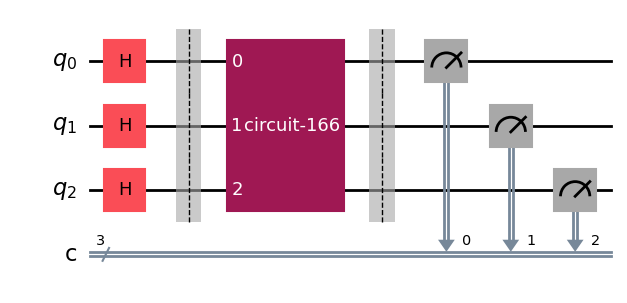

In [11]:
grover_cir = QuantumCircuit(n, n)

for i in range(n):
    grover_cir.h(i)

grover_cir.barrier()

for j in range(r_iter):
    grover_cir.append(encapsulated_gate, list(range(n)))
grover_cir.barrier()

for i in range(n):
    grover_cir.measure(i, i)

grover_cir.draw('mpl')

{'000': 792, '101': 31, '011': 36, '111': 25, '001': 38, '110': 41, '010': 29, '100': 32}


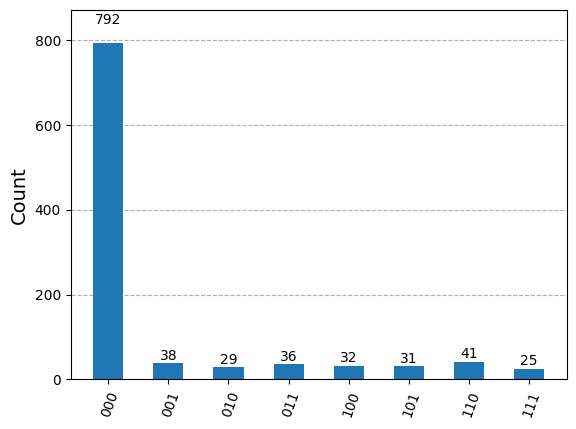

<Figure size 100x100 with 0 Axes>

In [12]:
statevectorsampler  = StatevectorSampler()
result = statevectorsampler.run([grover_cir]).result()
answer = result[0].data.c.get_counts()

print(answer)
plt.figure(figsize=(1, 1))  # Adjust width and height
plot_histogram(answer)

Are you obtaining the expected results?

Since we have defined the oracle to capture the w=|000> and the number of iterations is 1, the quantum simulator has returned
the expected w. Hence the result is correct. 

#### Use built-in Qiskit Grovers algorithm

In [13]:
import numpy as np
import math

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.primitives import Sampler, StatevectorSampler
from qiskit_algorithms import AmplificationProblem, Grover
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import GroverOptimizer

In [14]:
num_solutions = 1
num_qubits = 3
iterations = Grover.optimal_num_iterations(num_solutions=num_solutions, num_qubits=num_qubits)
print(iterations)

2


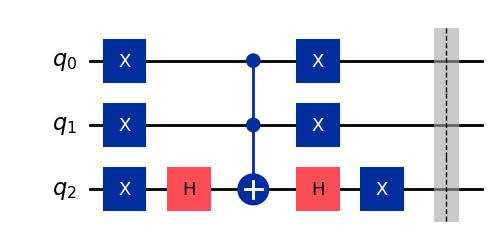

In [21]:
oracle = Uf_oracle(num_qubits)
oracle.draw('mpl')

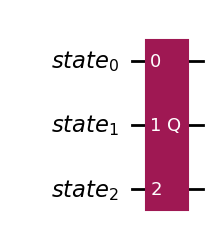

In [22]:
good_states = ['000']

grover_circuit = AmplificationProblem(oracle=oracle, is_good_state=good_states)

grover_circuit.grover_operator.draw('mpl')

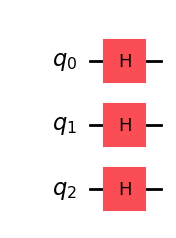

In [23]:
grover_circuit.state_preparation.draw('mpl')

In [24]:
sampler = Sampler()
grover = Grover(sampler=sampler)
result = grover.amplify(grover_circuit)

In [25]:
print(result)
print(result.top_measurement)
print('\n The correct results are:', result.circuit_results[0].keys())

{   'assignment': '000',
    'circuit_results': [   {   '000': np.float64(0.7812499999999983),
                               '001': np.float64(0.0312499999999999),
                               '010': np.float64(0.0312499999999999),
                               '011': np.float64(0.0312499999999999),
                               '100': np.float64(0.0312499999999999),
                               '101': np.float64(0.0312499999999999),
                               '110': np.float64(0.0312499999999999),
                               '111': np.float64(0.0312499999999999)}],
    'iterations': [1],
    'max_probability': np.float64(0.7812499999999983),
    'oracle_evaluation': True,
    'top_measurement': '000'}
000

 The correct results are: dict_keys(['000', '001', '010', '011', '100', '101', '110', '111'])


Are you obtaining the expected results?

Since we have defined the oracle to capture the w=|000> and the number of iterations is 2, the quantum simulator has returned
the expected w (now using the built-in Qiskit function). Hence the result is correct.

## Deliverable 2

Use Grover’s algorithm to maximize the following QUBO function: 

𝑄𝑈𝐵𝑂 =9𝑥0𝑥1−6𝑥0𝑥2 +5𝑥1𝑥2−14𝑥2 +11𝑥0 

Since this is a maximization problem and Qiskit minimizes the cost function, we need to negate the provided cost function

Is the result the expected? Why?

In [26]:
qubo = QuadraticProgram()

qubo.binary_var(name='x0')
qubo.binary_var(name='x1')
qubo.binary_var(name='x2')

qubo.minimize(linear={'x0': -11, 'x2': +14}, quadratic={('x0', 'x1'): -9, ('x0', 'x2'): +6, ('x1', 'x2'): -5})

print(qubo.export_as_lp_string())

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: CPLEX

Minimize
 obj: - 11 x0 + 14 x2 + [ - 18 x0*x1 + 12 x0*x2 - 10 x1*x2 ]/2
Subject To

Bounds
 0 <= x0 <= 1
 0 <= x1 <= 1
 0 <= x2 <= 1

Binaries
 x0 x1 x2
End



In [29]:
grover_optimizer = GroverOptimizer(6, num_iterations=10, sampler=Sampler())
results = grover_optimizer.solve(qubo)
print("x={}".format(results.x))
print("fval={}".format(results.fval))

x=[1. 1. 0.]
fval=-20.0
